<a href="https://colab.research.google.com/github/pumazzo/ISS-Python2026/blob/main/beira_idp_mapping_lesson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step-by-step lesson: mapping IDP sites in Beira with GeoPandas and OpenStreetMap

This notebook shows how to:

1. read the Excel file with `pandas`,
2. clean the columns needed for mapping,
3. convert the table into a `GeoDataFrame` with `geopandas`,
4. build a simple outline around the sites,
5. draw an OpenStreetMap basemap with `contextily`,
6. scale marker size by camp population,
7. color markers by **Spontaneous** vs **Planned** site classification.

The Excel file used here is:

`dtm-mozambique-site-assessment-round-1.xlsx`

## 1) Import the libraries

**Syntax recap**

- `import pandas as pd`: imports pandas and gives it the short alias `pd`.
- `import geopandas as gpd`: imports GeoPandas with alias `gpd`.
- `import matplotlib.pyplot as plt`: imports the plotting interface from Matplotlib.
- `import contextily as cx`: imports the package used to add web map tiles such as OpenStreetMap.

These aliases are common in data analysis notebooks, so students will see them often in tutorials and research code.

In [2]:
try:
  import contextily as cx
except:
  !pip install contextily
  pass


In [14]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

## 2) Read the Excel file

**Syntax recap**

- `pd.read_excel(...)` reads an Excel worksheet into a pandas `DataFrame`.
- `header=2` means: use the **third row** of the sheet as the column names.
- A pandas `DataFrame` is a table where columns can have different data types.

In this file, the first rows contain metadata and repeated headers. Using `header=2` gives us the real field names directly.

In [6]:
file_path = "dtm-mozambique-site-assessment-round-1.xlsx"

df = pd.read_excel(file_path, header=2)
df.head()

,SURVEY_DATE,SSID,SITE_NAME,ADM1_NAME,ADM1_CODE,ADM2_NAME,ADM2_CODE,ADM3_NAME,LAT_Y,LONG_X,...,ORIGIN_ADM2_CODE,ORIGIN_ADM3,RETURN_Y_N,PREVENT_RETURN,PERIOD_DISPLACEMENT,IDP_HH,IDP_IND,NEED1,NEED2,NEED3
0,2019-03-27,MOZ_S001,E. Secundaria Mutembe,Sofala,MZ009,Cidade Da Beira,MZ009701,NaN,-19.834500,34.850300,...,MZ009701,Beira city,Yes,House damaged/destroyed,Between 1 and 2 weeks,120,612,Net,Food,Blanket
1,2019-03-27,MOZ_S002,E. S. Matadouro,Sofala,MZ009,Cidade Da Beira,MZ009701,Inhamizua,-19.744444,34.856944,...,MZ009701,Inhamizua,Yes,House damaged/destroyed,Between 1 and 2 weeks,594,2512,Food,Shelter/NFI,Material construction
2,2019-03-27,MOZ_S003,E. S. AZEM,Sofala,MZ009,Cidade Da Beira,MZ009701,Nhaconjo,-19.758889,34.863056,...,MZ009701,Nhaconjo,Yes,House damaged/destroyed,Between 1 and 2 weeks,5,22,House,Medical assitance,Food
3,2019-03-27,MOZ_S004,E. S. Estoril,Sofala,MZ009,Cidade Da Beira,MZ009701,Estoril,-19.840000,34.895278,...,MZ009701,Estoril,No,House damaged/destroyed,Less than 1 week,30,125,Leave the temporary shelter,Construction Material,Food
4,2019-03-27,MOZ_S005,E. S. 25 Setembro,Sofala,MZ009,Cidade Da Beira,MZ009701,Chomba,-19.736667,34.828056,...,MZ009701,Chomba,Yes,House damaged/destroyed,Between 1 and 2 weeks,42,244,Tent,Water,Blankets


## 3) Select and clean the columns needed for the map

We need:

- `SITE_NAME`: the site name,
- `LAT_Y` and `LONG_X`: coordinates,
- `IDP_IND`: total number of individuals, used for marker size,
- `SITE_CLASSIFICATION`: used for marker color.

**Syntax recap**

- `df[[...]]` selects a subset of columns.
- `.copy()` creates an independent copy of the data.
- `pd.to_numeric(..., errors="coerce")` converts values to numbers and replaces invalid values with `NaN`.
- `.dropna(...)` removes rows with missing values in required columns.
- `.str.strip()` removes extra spaces from text fields.

In [7]:
sites = df[["SITE_NAME", "LAT_Y", "LONG_X", "IDP_IND", "SITE_CLASSIFICATION"]].copy()

sites["LAT_Y"] = pd.to_numeric(sites["LAT_Y"], errors="coerce")
sites["LONG_X"] = pd.to_numeric(sites["LONG_X"], errors="coerce")
sites["IDP_IND"] = pd.to_numeric(sites["IDP_IND"], errors="coerce")
sites["SITE_CLASSIFICATION"] = sites["SITE_CLASSIFICATION"].astype(str).str.strip()

sites = sites.dropna(subset=["LAT_Y", "LONG_X", "IDP_IND"])

sites.head()

,SITE_NAME,LAT_Y,LONG_X,IDP_IND,SITE_CLASSIFICATION
0,E. Secundaria Mutembe,-19.834500,34.850300,612,Spontaneous
1,E. S. Matadouro,-19.744444,34.856944,2512,Planned
2,E. S. AZEM,-19.758889,34.863056,22,Spontaneous
3,E. S. Estoril,-19.840000,34.895278,125,Spontaneous
4,E. S. 25 Setembro,-19.736667,34.828056,244,Planned


## 4) Quick exploratory checks

Before plotting, it is good practice to inspect the dataset.

**Syntax recap**

- `.shape` returns `(rows, columns)`.
- `.describe()` summarizes numeric columns.
- `.value_counts()` counts how many times each category appears.

This helps confirm that coordinates, population values, and classes look reasonable.

In [8]:
print("Shape:", sites.shape)
print()
print("Population summary")
display(sites["IDP_IND"].describe())
print()
print("Site classification counts")
display(sites["SITE_CLASSIFICATION"].value_counts(dropna=False))

Shape: (32, 5)

Population summary


,IDP_IND
count,32.000000
mean,698.312500
std,671.049608
min,22.000000
25%,236.750000
50%,432.000000
75%,1151.250000
max,2512.000000



Site classification counts


,count
SITE_CLASSIFICATION,
Spontaneous,27
Planned,5


## 5) Convert the table into a GeoDataFrame

GeoPandas stores geometries such as points, lines, and polygons together with tabular data.

**Syntax recap**

- `gpd.points_from_xy(x, y)` creates geometric point objects from longitude and latitude.
- `gpd.GeoDataFrame(...)` builds a spatial table.
- `crs="EPSG:4326"` sets the coordinate reference system to latitude/longitude in WGS84.

This is the standard CRS used by GPS coordinates.

In [9]:
gdf = gpd.GeoDataFrame(
    sites,
    geometry=gpd.points_from_xy(sites["LONG_X"], sites["LAT_Y"]),
    crs="EPSG:4326"
)

gdf.head()

,SITE_NAME,LAT_Y,LONG_X,IDP_IND,SITE_CLASSIFICATION,geometry
0,E. Secundaria Mutembe,-19.834500,34.850300,612,Spontaneous,POINT (34.8503 -19.8345)
1,E. S. Matadouro,-19.744444,34.856944,2512,Planned,POINT (34.85694 -19.74444)
2,E. S. AZEM,-19.758889,34.863056,22,Spontaneous,POINT (34.86306 -19.75889)
3,E. S. Estoril,-19.840000,34.895278,125,Spontaneous,POINT (34.89528 -19.84)
4,E. S. 25 Setembro,-19.736667,34.828056,244,Planned,POINT (34.82806 -19.73667)


## 6) Reproject to Web Mercator and create a simple outline

OpenStreetMap tiles are served in **Web Mercator**, so we reproject the site points to `EPSG:3857`.

We also create a very simple area outline:

1. merge all site points,
2. compute the convex hull,
3. add a small buffer around it.

**Syntax recap**

- `.to_crs(epsg=3857)` changes the CRS.
- `.union_all()` merges all geometries into one geometry.
- `.convex_hull` builds the smallest convex polygon containing the points.
- `.buffer(distance)` expands the geometry by a distance in projected units, here meters.

In [10]:
gdf_3857 = gdf.to_crs(epsg=3857)

hull_3857 = gdf_3857.geometry.union_all().convex_hull
outline_3857 = gpd.GeoSeries([hull_3857.buffer(1500)], crs="EPSG:3857")

## 7) Build marker sizes from camp population

We want larger camps to appear as larger markers.

A common approach is to rescale population into a marker-size interval, for example from `40` to `400`.

**Syntax recap**

- `series.min()` and `series.max()` return the minimum and maximum values.
- Arithmetic on whole pandas columns is vectorized, which means it is applied to all rows at once.
- `if ... else ...` is used here to avoid division by zero when all populations are equal.

In [11]:
pop = gdf_3857["IDP_IND"]

min_size = 40
max_size = 400


gdf_3857["marker_size"] = min_size + (pop - pop.min()) * (max_size - min_size) / (pop.max() - pop.min())

gdf_3857[["SITE_NAME", "IDP_IND", "marker_size"]].head()

,SITE_NAME,IDP_IND,marker_size
0,E. Secundaria Mutembe,612,125.301205
1,E. S. Matadouro,2512,400.000000
2,E. S. AZEM,22,40.000000
3,E. S. Estoril,125,54.891566
4,E. S. 25 Setembro,244,72.096386


## 8) Assign marker colors from site classification

We map categories to colors manually.

Here we use:

- **Spontaneous** → red
- **Planned** → blue
- anything else → gray

**Syntax recap**

- A Python dictionary stores key-value pairs.
- `.map(dictionary)` replaces each category with the value associated with it.
- `.fillna(...)` is useful for a default value when a category is not found.

In [12]:
color_map = {
    "Spontaneous": "red",
    "Planned": "blue",
}

gdf_3857["marker_color"] = (
    gdf_3857["SITE_CLASSIFICATION"]
    .map(color_map)
    .fillna("gray")
)

gdf_3857[["SITE_NAME", "SITE_CLASSIFICATION", "marker_color"]].head()

,SITE_NAME,SITE_CLASSIFICATION,marker_color
0,E. Secundaria Mutembe,Spontaneous,red
1,E. S. Matadouro,Planned,blue
2,E. S. AZEM,Spontaneous,red
3,E. S. Estoril,Spontaneous,red
4,E. S. 25 Setembro,Planned,blue


## 9) Plot the OpenStreetMap basemap, outline, and scaled points

This cell combines everything.

**Syntax recap**

- `plt.subplots(...)` creates a figure and axes.
- `ax.set_xlim(...)` and `ax.set_ylim(...)` define the visible map extent.
- `cx.add_basemap(...)` adds map tiles to the Matplotlib axes.
- `GeoDataFrame.plot(...)` draws geometries on the axes.
- `ax.text(...)` adds labels.
- `ax.scatter(...)` is useful for custom legends because it can create marker samples manually.

Note that GeoPandas can plot points with variable size using the `markersize=` argument and variable color using `color=`.

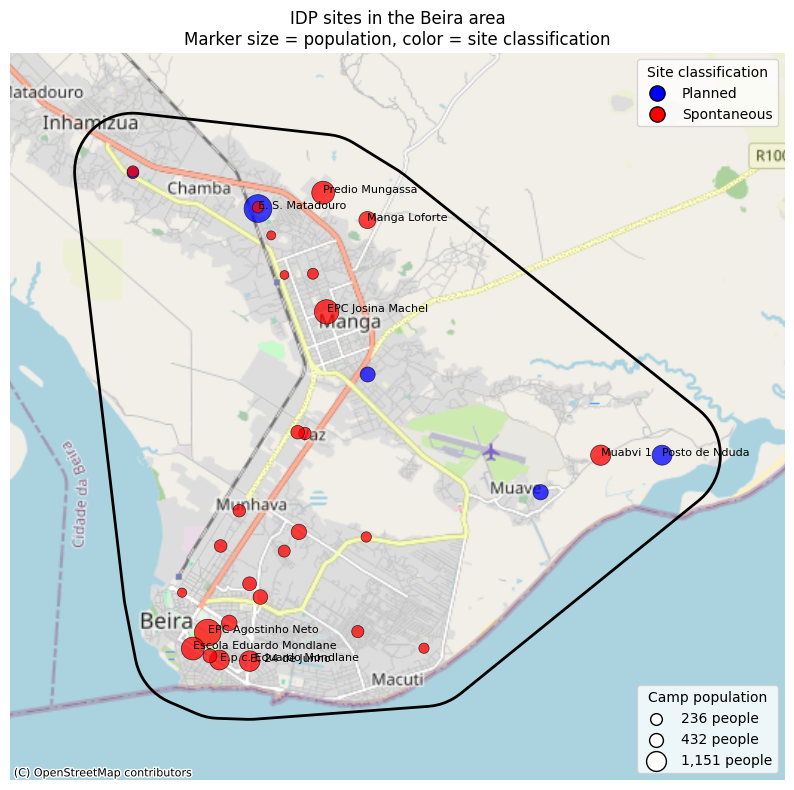

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

# Set map extent from the buffered outline
minx, miny, maxx, maxy = outline_3857.total_bounds
padx = (maxx - minx) * 0.10
pady = (maxy - miny) * 0.10
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)

# Basemap
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

# Outline
outline_3857.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)

# Points: size by population, color by classification
gdf_3857.plot(
    ax=ax,
    markersize=gdf_3857["marker_size"],
    color=gdf_3857["marker_color"],
    alpha=0.75,
    edgecolor="black",
    linewidth=0.5,
)

#  label the 10 largest camps to reduce clutter
largest_sites = gdf_3857.nlargest(10, "IDP_IND")
for _, r in largest_sites.iterrows():
    ax.text(
        r.geometry.x,
        r.geometry.y,
        str(r["SITE_NAME"]),
        fontsize=8,
    )

# Simple color legend
planned_handle = ax.scatter([], [], s=120, c="blue", edgecolors="black", label="Planned")
spont_handle = ax.scatter([], [], s=120, c="red", edgecolors="black", label="Spontaneous")

# Simple size legend using representative populations
size_values = [
    int(gdf_3857["IDP_IND"].quantile(0.25)),
    int(gdf_3857["IDP_IND"].quantile(0.50)),
    int(gdf_3857["IDP_IND"].quantile(0.75)),
]
size_values = sorted(set(size_values))

size_handles = []
for value in size_values:

    s = min_size + (value - pop.min()) * (max_size - min_size) / (pop.max() - pop.min())
    size_handles.append(ax.scatter([], [], s=s, c="white", edgecolors="black", label=f"{value:,} people"))

legend1 = ax.legend(handles=[planned_handle, spont_handle], title="Site classification", loc="upper right")
ax.add_artist(legend1)
ax.legend(handles=size_handles, title="Camp population", loc="lower right")

ax.set_axis_off()
ax.set_title("IDP sites in the Beira area\nMarker size = population, color = site classification")

plt.show()